# Notebook 6 — Model Compression
## AI and Sustainability — EEEM073 | University of Surrey
### Project: Explainable and Efficient AI for Time Series Forecasting of Wind and Solar Energy in the TenneT Region, Germany

**Purpose of this notebook:**
- Apply compression techniques to all three models from Notebook 4
- Linear Regression: Feature Selection + LASSO regularisation
- MLP: Pruning + Pruning with Quantization + Knowledge Distillation
- LSTM: Pruning + Pruning with Quantization + Knowledge Distillation
- Compare all compressed models vs originals on size, speed and accuracy
- Discuss sustainability implications of model compression

## Step 1 — Import Libraries

In [1]:
# ============================================================
# Import all required libraries
# tf_keras required for tfmot compatibility
# Install if not already installed
# ============================================================
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'tf_keras'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'tensorflow-model-optimization'], check=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import time
import zipfile
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

plt.style.use('seaborn-v0_8-whitegrid')
print('All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')

All libraries imported successfully!
TensorFlow version: 2.21.0


### Why Model Compression?

Model compression is a core technique in sustainable AI. The three models trained in Notebook 4 achieve high accuracy but vary significantly in size and computational cost:

- **Linear Regression** — 1.64 KB, 0.14s training, ~1ms inference
- **MLP** — 208 KB, 36s training, ~718ms inference
- **LSTM** — 1,623 KB, 671s training, ~2,571ms inference

Three compression techniques are applied per neural network model, following Lab 07:
1. **Pruning** — magnitude-based weight pruning (80% sparsity), implemented in pure TensorFlow
2. **Pruning + Quantization** — MLP uses TFLite int8 conversion; LSTM uses float16 weight quantization (TFLite SELECT_TF_OPS not supported on Windows TF 2.11 for LSTM)
3. **Knowledge Distillation** — a smaller student model learns from the larger teacher model

For Linear Regression, two techniques are applied:
1. **Feature Selection** — SHAP-guided reduction from 34 to 10 features
2. **LASSO** — L1 regularisation to shrink redundant coefficients to zero

Compressing models directly reduces the electricity consumed by the AI system itself — contributing to SDG 13 (Climate Action) and enabling deployment on low-power edge hardware at grid substations.

## Step 2 — Load Data and Original Models

In [2]:
# ============================================================
# Load data from npy files — consistent 34 features
# Load both scalers for inverse transformation
# Load original trained models from Notebook 4
# ============================================================

# Load correctly scaled arrays
X_train = np.load('X_train.npy')
X_val   = np.load('X_val.npy')
X_test  = np.load('X_test.npy')
y_train = np.load('y_train.npy')
y_val   = np.load('y_val.npy')
y_test  = np.load('y_test.npy')

# Load scalers
feature_scaler = joblib.load('feature_scaler.pkl')
target_scaler  = joblib.load('target_scaler.pkl')

# Load feature and target column names
feature_cols = pd.read_csv('feature_columns.csv').iloc[:, 0].tolist()
target_cols  = ['wind_onshore_mwh', 'wind_offshore_mwh', 'solar_mwh']

# Load unscaled test data for MWh evaluation
test_unscaled = pd.read_csv('data_test.csv')
y_test_actual = test_unscaled[target_cols].values

# Load original trained models
lr_original   = joblib.load('model_linear_regression.pkl')
mlp_original  = load_model('model_mlp.keras')
lstm_original = load_model('model_lstm.keras')

# Load original predictions and actual values from Notebook 4
lr_pred   = np.load('lr_pred.npy')
mlp_pred  = np.load('mlp_pred.npy')
lstm_pred = np.load('lstm_pred.npy')
y_test_actual_orig      = np.load('y_test_actual.npy')
y_test_actual_lstm_orig = np.load('y_test_actual_lstm.npy')

# Original inference times from Notebook 4 (in ms)
lr_orig_inf   = 1.00
mlp_orig_inf  = 718.12
lstm_orig_inf = 2571.00

# Get original model sizes in KB
lr_orig_size   = os.path.getsize('model_linear_regression.pkl') / 1024
mlp_orig_size  = os.path.getsize('model_mlp.keras') / 1024
lstm_orig_size = os.path.getsize('model_lstm.keras') / 1024

print('Data and models loaded successfully!')
print(f'Features: {len(feature_cols)}')
print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')
print(f'LR original size:   {lr_orig_size:.2f} KB')
print(f'MLP original size:  {mlp_orig_size:.2f} KB')
print(f'LSTM original size: {lstm_orig_size:.2f} KB')

Data and models loaded successfully!
Features: 34
X_train: (26112, 34) | X_val: (4368, 34) | X_test: (4416, 34)
LR original size:   1.64 KB
MLP original size:  208.54 KB
LSTM original size: 1623.37 KB


## Step 3 — Helper Functions

In [3]:
# ============================================================
# Helper functions used throughout notebook 6
# Consistent with Notebooks 4 and 5
# ============================================================

def inverse_transform_targets(y_scaled, target_scaler):
    """
    Inverse transform scaled predictions back to MWh values.
    Uses the dedicated target_scaler fitted in Notebook 1.
    """
    return target_scaler.inverse_transform(y_scaled)

def evaluate_model(y_true, y_pred, target_cols):
    """
    Calculate MAE, RMSE and R2 for each target column.
    Returns a dictionary of results.
    """
    results = {}
    for i, col in enumerate(target_cols):
        mae  = mean_absolute_error(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        r2   = r2_score(y_true[:, i], y_pred[:, i])
        results[col] = {'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R2': round(r2, 4)}
    return results

def create_sequences(X, y, lookback):
    """
    Create 3D sequences for LSTM input.
    Same function used in Notebooks 4 and 5.
    """
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

def measure_inference_time(predict_fn, X_input, n_runs=10):
    """
    Measure average inference time over n_runs.
    Returns time in milliseconds.
    """
    times = []
    for _ in range(n_runs):
        start = time.time()
        predict_fn(X_input)
        times.append((time.time() - start) * 1000)
    return np.mean(times)

def apply_magnitude_pruning(model, sparsity=0.80):
    """
    Apply magnitude-based weight pruning.
    Sets the smallest weights to zero to achieve target sparsity.
    Same principle as Lab 07 tfmot pruning.
    """
    pruned_weights = []
    for w in model.get_weights():
        if len(w.shape) > 1:  # Only prune weight matrices not biases
            threshold = np.percentile(np.abs(w), sparsity * 100)
            mask = np.abs(w) >= threshold
            pruned_weights.append(w * mask)
        else:
            pruned_weights.append(w)
    return pruned_weights

# Compute original results for comparison
lr_orig_results   = evaluate_model(y_test_actual_orig,      lr_pred,   target_cols)
mlp_orig_results  = evaluate_model(y_test_actual_orig,      mlp_pred,  target_cols)
lstm_orig_results = evaluate_model(y_test_actual_lstm_orig, lstm_pred, target_cols)

print('Helper functions ready!')
print('Original model results loaded for comparison.')
print(f'LR   avg R2: {round(sum(lr_orig_results[c]["R2"]   for c in target_cols)/3, 4)}')
print(f'MLP  avg R2: {round(sum(mlp_orig_results[c]["R2"]  for c in target_cols)/3, 4)}')
print(f'LSTM avg R2: {round(sum(lstm_orig_results[c]["R2"] for c in target_cols)/3, 4)}')

Helper functions ready!
Original model results loaded for comparison.
LR   avg R2: 0.9705
MLP  avg R2: 0.9503
LSTM avg R2: 0.9435


## Step 4 — Linear Regression Compression

Two compression techniques are applied to Linear Regression:
1. **Feature Selection** — SHAP-guided reduction from 34 to 10 features
2. **LASSO** — L1 regularisation which shrinks redundant coefficients to exactly zero

In [4]:
# ============================================================
# Step 4.1 — Linear Regression: Feature Selection
# Top 10 features from SHAP analysis in Notebook 5 (Figure 19)
# These features account for the vast majority of predictive power
# ============================================================

top_features = [
    'wind_onshore_mwh_lag1',
    'wind_offshore_mwh_lag1',
    'solar_mwh_lag1',
    'wind_onshore_mwh_lag24',
    'wind_offshore_mwh_lag24',
    'solar_mwh_lag24',
    'kiel_wind_speed_100m_km_h',
    'munich_shortwave_radiation_w_m²',
    'hour_sin',
    'hour_cos'
]

# Get indices of top features
top_indices = [feature_cols.index(f) for f in top_features]
X_train_fs  = X_train[:, top_indices]
X_val_fs    = X_val[:, top_indices]
X_test_fs   = X_test[:, top_indices]

print('Step 4.1 — Feature Selection Linear Regression')
print(f'Features: {len(feature_cols)} -> {len(top_features)}')

start_time = time.time()
lr_fs = LinearRegression()
lr_fs.fit(X_train_fs, y_train)
lr_fs_train_time = time.time() - start_time

lr_fs_inf_time    = measure_inference_time(lambda X: lr_fs.predict(X), X_test_fs)
lr_fs_pred_scaled = lr_fs.predict(X_test_fs)
lr_fs_pred        = np.clip(inverse_transform_targets(lr_fs_pred_scaled, target_scaler), 0, None)
lr_fs_results     = evaluate_model(y_test_actual, lr_fs_pred, target_cols)

joblib.dump(lr_fs, 'model_lr_feature_selection.pkl')
lr_fs_size = os.path.getsize('model_lr_feature_selection.pkl') / 1024

print(f'Original: {lr_orig_size:.2f} KB | Compressed: {lr_fs_size:.2f} KB | Reduction: {((lr_orig_size-lr_fs_size)/lr_orig_size*100):.1f}%')
print(f'Inference: {lr_fs_inf_time:.2f} ms (original: {lr_orig_inf:.2f} ms)')
print('\nResults:')
for col, m in lr_fs_results.items():
    orig = lr_orig_results[col]
    print(f'  {col:25s} MAE: {m["MAE"]:7.2f} | RMSE: {m["RMSE"]:7.2f} | R2: {m["R2"]:.4f} (orig: {orig["R2"]:.4f}, diff: {m["R2"]-orig["R2"]:+.4f})')

Step 4.1 — Feature Selection Linear Regression
Features: 34 -> 10
Original: 1.64 KB | Compressed: 0.89 KB | Reduction: 45.7%
Inference: 0.70 ms (original: 1.00 ms)

Results:
  wind_onshore_mwh          MAE:  394.02 | RMSE:  560.10 | R2: 0.9829 (orig: 0.9845, diff: -0.0016)
  wind_offshore_mwh         MAE:  257.77 | RMSE:  372.10 | R2: 0.9464 (orig: 0.9477, diff: -0.0013)
  solar_mwh                 MAE:  380.07 | RMSE:  664.40 | R2: 0.9732 (orig: 0.9792, diff: -0.0060)


In [5]:
# ============================================================
# Step 4.2 — Linear Regression: LASSO (L1 Regularisation)
# LASSO adds L1 penalty which shrinks small coefficients to zero
# This performs automatic feature selection within the model
# alpha=0.001 is a mild regularisation — balances sparsity and accuracy
# ============================================================

print('Step 4.2 — LASSO Regularisation')
print('L1 penalty shrinks redundant coefficients to exactly zero')

start_time = time.time()
lr_lasso = Lasso(alpha=0.001, max_iter=5000, random_state=42)
lr_lasso.fit(X_train, y_train)
lr_lasso_train_time = time.time() - start_time

zero_coefs  = np.sum(np.abs(lr_lasso.coef_) < 1e-6)
total_coefs = lr_lasso.coef_.size
print(f'Zero coefficients: {zero_coefs}/{total_coefs} ({zero_coefs/total_coefs*100:.1f}% sparsity)')

lr_lasso_inf_time    = measure_inference_time(lambda X: lr_lasso.predict(X), X_test)
lr_lasso_pred_scaled = lr_lasso.predict(X_test)
lr_lasso_pred        = np.clip(inverse_transform_targets(lr_lasso_pred_scaled, target_scaler), 0, None)
lr_lasso_results     = evaluate_model(y_test_actual, lr_lasso_pred, target_cols)

joblib.dump(lr_lasso, 'model_lr_lasso.pkl')
lr_lasso_size = os.path.getsize('model_lr_lasso.pkl') / 1024

print(f'Original: {lr_orig_size:.2f} KB | LASSO: {lr_lasso_size:.2f} KB | Reduction: {((lr_orig_size-lr_lasso_size)/lr_orig_size*100):.1f}%')
print(f'Inference: {lr_lasso_inf_time:.2f} ms (original: {lr_orig_inf:.2f} ms)')
print('\nResults:')
for col, m in lr_lasso_results.items():
    orig = lr_orig_results[col]
    print(f'  {col:25s} MAE: {m["MAE"]:7.2f} | RMSE: {m["RMSE"]:7.2f} | R2: {m["R2"]:.4f} (orig: {orig["R2"]:.4f}, diff: {m["R2"]-orig["R2"]:+.4f})')

Step 4.2 — LASSO Regularisation
L1 penalty shrinks redundant coefficients to exactly zero
Zero coefficients: 90/102 (88.2% sparsity)
Original: 1.64 KB | LASSO: 1.51 KB | Reduction: 7.6%
Inference: 2.34 ms (original: 1.00 ms)

Results:
  wind_onshore_mwh          MAE:  408.13 | RMSE:  576.38 | R2: 0.9819 (orig: 0.9845, diff: -0.0026)
  wind_offshore_mwh         MAE:  261.76 | RMSE:  373.08 | R2: 0.9461 (orig: 0.9477, diff: -0.0016)
  solar_mwh                 MAE:  379.36 | RMSE:  684.65 | R2: 0.9715 (orig: 0.9792, diff: -0.0077)


### Interpretation — Linear Regression Compression

**Feature Selection** (Step 4.1) reduces the input from 34 to 10 features based on SHAP global importance (Figures 19a-c in Notebook 5). The 10 selected features — lag-1, lag-24 values for each target, Kiel wind speed, Munich shortwave radiation, and hour cyclic encodings — capture the dominant physical relationships. This is justified by the ACF analysis in Notebook 3 which confirmed these specific lags as the most informative.

**LASSO** (Step 4.2) adds an L1 penalty during training that forces the coefficients of unimportant features towards zero. Unlike feature selection which manually removes features, LASSO learns the sparsity automatically from the data. The sparsity achieved confirms that a large number of the 34 features contribute negligibly to prediction — consistent with the SHAP findings in Notebook 5.

**Sustainability argument:** Both techniques reduce the number of floating-point multiplications per prediction. In a production grid management system making 24 forecasts per day, this reduction compounds into meaningful energy savings over months and years of operation.

## Step 5 — MLP Compression

Three compression techniques are applied to the MLP:
1. **Pruning** — magnitude-based weight pruning (80% sparsity), then fine-tuned to recover accuracy
2. **Pruning + Quantization** — TFLite int8 dynamic range quantization applied on top of the pruned model
3. **Knowledge Distillation** — a smaller student MLP (32→16 neurons) learns from the original teacher MLP (128→64→32 neurons)

In [6]:
# ============================================================
# Step 5.1 — MLP Pruning (Weight Magnitude Pruning)
# Manual implementation — avoids tfmot compatibility issues
# on Windows with TF 2.11+
# Same concept as Lab 07: remove small weights by setting
# them to zero, then retrain to recover accuracy
# 80% sparsity target — same as Lab 07 PolynomialDecay
# ============================================================

print('Step 5.1 — MLP Pruning (80% sparsity)')

# Rebuild MLP with same architecture as original
mlp_pruned_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation='linear')
])

# Apply pruning to original weights
pruned_weights = apply_magnitude_pruning(mlp_original, sparsity=0.80)
mlp_pruned_model.set_weights(pruned_weights)

# Count sparsity achieved
total_params = sum(w.size for w in pruned_weights if len(w.shape) > 1)
zero_params  = sum(np.sum(w == 0) for w in pruned_weights if len(w.shape) > 1)
print(f'Sparsity achieved: {zero_params/total_params*100:.1f}%')

# Fine-tune with pruned weights to recover accuracy
mlp_pruned_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='mse',
    metrics=['mae']
)

start_time = time.time()
mlp_pruned_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
    ],
    verbose=1
)
mlp_pruned_train_time = time.time() - start_time

# Save and evaluate
mlp_pruned_model.save('model_mlp_pruned.keras')
mlp_pruned_size = os.path.getsize('model_mlp_pruned.keras') / 1024

mlp_pruned_inf_time    = measure_inference_time(lambda X: mlp_pruned_model.predict(X, verbose=0), X_test)
mlp_pruned_pred_scaled = mlp_pruned_model.predict(X_test, verbose=0)
mlp_pruned_pred        = np.clip(inverse_transform_targets(mlp_pruned_pred_scaled, target_scaler), 0, None)
mlp_pruned_results     = evaluate_model(y_test_actual, mlp_pruned_pred, target_cols)

print(f'\nOriginal: {mlp_orig_size:.2f} KB | Pruned: {mlp_pruned_size:.2f} KB | Reduction: {((mlp_orig_size-mlp_pruned_size)/mlp_orig_size*100):.1f}%')
print(f'Inference: {mlp_pruned_inf_time:.2f} ms (original: {mlp_orig_inf:.2f} ms)')
print('\nResults:')
for col, m in mlp_pruned_results.items():
    orig = mlp_orig_results[col]
    print(f'  {col:25s} R2: {m["R2"]:.4f} (orig: {orig["R2"]:.4f}, diff: {m["R2"]-orig["R2"]:+.4f})')

Step 5.1 — MLP Pruning (80% sparsity)
Sparsity achieved: 80.0%
Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0076 - mae: 0.0606 - val_loss: 0.0030 - val_mae: 0.0399 - learning_rate: 0.0010
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0053 - mae: 0.0515 - val_loss: 0.0032 - val_mae: 0.0398 - learning_rate: 0.0010
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0051 - mae: 0.0503 - val_loss: 0.0029 - val_mae: 0.0380 - learning_rate: 0.0010
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0049 - mae: 0.0490 - val_loss: 0.0024 - val_mae: 0.0351 - learning_rate: 0.0010
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0047 - mae: 0.0484 - val_loss: 0.0029 - val_mae: 0.0393 - learning_rate: 0.0010
Epoch 6/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0047 - mae: 0.0480 - val_loss: 0.0028 - val_mae: 0.0367 - learning_rate: 0.0010
Epoch 7/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0046 - mae: 0.0475 - va

In [7]:
# ============================================================
# Step 5.2 — MLP Pruning + Quantization
# Applies dynamic range quantization on top of the pruned model
# Converts float32 weights to int8 using TFLite
# Results in maximum compression — Lab 07 Challenge 03
# TFLite interpreter used for inference
# ============================================================

print('Step 5.2 — MLP Pruning + Quantization (Lab 07 technique)')
print('Dynamic range quantization: float32 -> int8 weights')

# Convert pruned model to TFLite with quantization
converter = tf.lite.TFLiteConverter.from_keras_model(mlp_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
mlp_quantized_tflite = converter.convert()

mlp_quant_file = 'model_mlp_pruned_quantized.tflite'
with open(mlp_quant_file, 'wb') as f:
    f.write(mlp_quantized_tflite)

mlp_quant_size = os.path.getsize(mlp_quant_file) / 1024

# TFLite inference function
def tflite_predict_mlp(X_input):
    """Run inference using TFLite interpreter for quantized MLP."""
    interpreter = tf.lite.Interpreter(model_content=mlp_quantized_tflite)
    interpreter.allocate_tensors()
    input_idx  = interpreter.get_input_details()[0]['index']
    output_idx = interpreter.get_output_details()[0]['index']
    preds = []
    for i in range(len(X_input)):
        inp = np.array([X_input[i]], dtype=np.float32)
        interpreter.set_tensor(input_idx, inp)
        interpreter.invoke()
        preds.append(interpreter.get_tensor(output_idx)[0])
    return np.array(preds)

# Evaluate on subset for speed
X_test_sub = X_test[:500]
y_test_sub = y_test_actual[:500]

start_inf = time.time()
mlp_quant_pred_scaled = tflite_predict_mlp(X_test_sub)
mlp_quant_inf_time = (time.time() - start_inf) / len(X_test_sub) * 1000

mlp_quant_pred    = np.clip(inverse_transform_targets(mlp_quant_pred_scaled, target_scaler), 0, None)
mlp_quant_results = evaluate_model(y_test_sub, mlp_quant_pred, target_cols)

print(f'\nOriginal: {mlp_orig_size:.2f} KB | Quantized: {mlp_quant_size:.2f} KB | Reduction: {((mlp_orig_size-mlp_quant_size)/mlp_orig_size*100):.1f}%')
print(f'Inference: {mlp_quant_inf_time:.2f} ms (original: {mlp_orig_inf:.2f} ms)')
print('\nResults (on 500-sample subset):')
for col, m in mlp_quant_results.items():
    orig = mlp_orig_results[col]
    print(f'  {col:25s} R2: {m["R2"]:.4f} (orig: {orig["R2"]:.4f}, diff: {m["R2"]-orig["R2"]:+.4f})')

Step 5.2 — MLP Pruning + Quantization (Lab 07 technique)
Dynamic range quantization: float32 -> int8 weights
INFO:tensorflow:Assets written to: C:\Users\Aneel\AppData\Local\Temp\tmp6uyq0sr9\assets


INFO:tensorflow:Assets written to: C:\Users\Aneel\AppData\Local\Temp\tmp6uyq0sr9\assets


Saved artifact at 'C:\Users\Aneel\AppData\Local\Temp\tmp6uyq0sr9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 34), dtype=tf.float32, name='keras_tensor_42')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2822752791792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2822752788624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2822752783344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2822752791088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2822752796368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2822752794080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2822752794960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2822752792672: TensorSpec(shape=(), dtype=tf.resource, name=None)

Original: 208.54 KB | Quantized: 20.59 KB | Reduction: 90.1%
Inference: 0.03 ms (original: 718.12 ms)

Results (on 500-sample subset):
  wind_onshor

In [8]:
# ============================================================
# Step 5.3 — MLP Knowledge Distillation
# Teacher: original MLP (larger model)
# Student: smaller MLP (32->16 neurons vs 128->64->32)
# Distiller class from Lab 07 Challenge 04
# Student learns from teacher soft predictions (MSE distillation)
# alpha=0.6 balances hard labels vs soft teacher knowledge
# temperature=5 softens teacher probability distributions
# ============================================================

print('Step 5.3 — MLP Knowledge Distillation (Lab 07 technique)')
print('Teacher: original MLP | Student: smaller MLP (32->16 neurons)')

class DistillerRegression(tf.keras.Model):
    """
    Knowledge Distillation model for regression.
    Adapted from Lab 07 Distiller class for multi-output regression.
    Student learns from teacher soft outputs using MSE distillation loss.
    """
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(self, optimizer, student_loss_fn, distillation_loss_fn, alpha=0.6, temperature=5):
        super().compile(optimizer=optimizer)
        self.student_loss_fn      = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha                = alpha
        self.temperature          = temperature

    def train_step(self, data):
        x, y = data
        teacher_pred = self.teacher(x, training=False)
        with tf.GradientTape() as tape:
            student_pred      = self.student(x, training=True)
            student_loss      = self.student_loss_fn(y, student_pred)
            distillation_loss = self.distillation_loss_fn(
                teacher_pred / self.temperature,
                student_pred / self.temperature
            ) * (self.temperature ** 2)
            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss
        grads = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.student.trainable_variables))
        return {'loss': loss, 'student_loss': student_loss, 'distillation_loss': distillation_loss}

    def test_step(self, data):
        x, y = data
        student_pred = self.student(x, training=False)
        loss = self.student_loss_fn(y, student_pred)
        return {'loss': loss}

    def call(self, x):
        return self.student(x)

# Define student MLP — significantly smaller than teacher
mlp_student = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(3, activation='linear')
], name='mlp_student')

distiller_mlp = DistillerRegression(student=mlp_student, teacher=mlp_original)
distiller_mlp.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    student_loss_fn=tf.keras.losses.MeanSquaredError(),
    distillation_loss_fn=tf.keras.losses.MeanSquaredError(),
    alpha=0.6,
    temperature=5
)

start_time = time.time()
distiller_mlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)
mlp_distil_train_time = time.time() - start_time

# Save and evaluate student model
mlp_student.save('model_mlp_distilled.keras')
mlp_distil_size = os.path.getsize('model_mlp_distilled.keras') / 1024

mlp_distil_inf_time    = measure_inference_time(lambda X: mlp_student.predict(X, verbose=0), X_test)
mlp_distil_pred_scaled = mlp_student.predict(X_test, verbose=0)
mlp_distil_pred        = np.clip(inverse_transform_targets(mlp_distil_pred_scaled, target_scaler), 0, None)
mlp_distil_results     = evaluate_model(y_test_actual, mlp_distil_pred, target_cols)

print(f'\nOriginal: {mlp_orig_size:.2f} KB | Distilled: {mlp_distil_size:.2f} KB | Reduction: {((mlp_orig_size-mlp_distil_size)/mlp_orig_size*100):.1f}%')
print(f'Inference: {mlp_distil_inf_time:.2f} ms (original: {mlp_orig_inf:.2f} ms)')
print('\nResults:')
for col, m in mlp_distil_results.items():
    orig = mlp_orig_results[col]
    print(f'  {col:25s} R2: {m["R2"]:.4f} (orig: {orig["R2"]:.4f}, diff: {m["R2"]-orig["R2"]:+.4f})')

Step 5.3 — MLP Knowledge Distillation (Lab 07 technique)
Teacher: original MLP | Student: smaller MLP (32->16 neurons)
Epoch 1/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - distillation_loss: 0.0070 - loss: 0.0086 - student_loss: 0.0096 - val_loss: 0.0000e+00
Epoch 2/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - distillation_loss: 0.0036 - loss: 0.0043 - student_loss: 0.0048 - val_loss: 0.0000e+00
Epoch 3/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - distillation_loss: 0.0020 - loss: 0.0034 - student_loss: 0.0043 - val_loss: 0.0000e+00
Epoch 4/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - distillation_loss: 0.0030 - loss: 0.0038 - student_loss: 0.0043 - val_loss: 0.0000e+00
Epoch 5/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - distillation_loss: 0.0019 - loss: 0.0026 - student_loss: 0.0031 - val_loss: 0.0000e+00
Epoch 6/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - distillation_loss: 0.0013 - loss: 0.0019 - student_loss: 0.0023 - val_loss: 0.0000e+00
Epoch 7/50
408/408 ━━━━━━━━━━━━━━━━

### Interpretation — MLP Compression

**Pruning** (Step 5.1) applies magnitude-based weight pruning — setting the smallest 80% of weights by magnitude to zero, then fine-tuning for 10 epochs to recover accuracy. This achieves the same goal as Lab 07 Challenge 02 (80% sparsity target) using pure TensorFlow to avoid Windows compatibility issues with tensorflow-model-optimization. Note: the pruned Keras model file shows no size reduction because zero weights are still stored explicitly in the .keras format — the compression benefit is fully realised in Step 5.2 where TFLite removes zero weights achieving 90.1% size reduction.

**Pruning + Quantization** (Step 5.2) applies dynamic range quantization to the pruned MLP model using `tf.lite.Optimize.DEFAULT`, converting float32 weights to int8. The TFLite interpreter is used for inference. This directly mirrors Lab 07 Challenge 03 and achieves the maximum compression ratio — 90.1% size reduction (208 KB to 21 KB) with near-zero inference time (0.03ms vs 718ms original), making it the most impactful technique for production deployment.

**Knowledge Distillation** (Step 5.3) trains a smaller student MLP (32 -> 16 neurons) to mimic the original teacher MLP (128 -> 64 -> 32 neurons). The student learns from both the true labels (hard loss, weight alpha=0.6) and the teacher's soft predictions (distillation loss, weight 0.4). This mirrors Lab 07 Challenge 04. The student shows a larger than expected accuracy drop for wind targets (R²=0.7853 vs 0.9462 original), reflecting the challenge of compressing a model that already has relatively few parameters — the 32→16 student is too small to capture the full wind generation complexity. Solar prediction is better preserved (R²=0.9346). For production deployment, the pruned + quantized model (Step 5.2) is recommended over distillation for MLP.

**Sustainability:** All three techniques reduce inference computation. Pruning and quantization reduce the number of active parameters and use lower precision arithmetic. Knowledge distillation produces an inherently smaller architecture. The Pruning + Quantization approach is the most sustainable option — achieving 90.1% size reduction while preserving acceptable accuracy.

## Step 6 — LSTM Compression

Three compression techniques are applied to the LSTM:
1. **Pruning** — magnitude-based weight pruning (80% sparsity), then fine-tuned to recover accuracy
2. **Pruning + Quantization** — float16 weight quantization applied on top of the pruned model (TFLite int8 not supported for LSTM on Windows TF 2.11+)
3. **Knowledge Distillation** — a smaller student LSTM (32 units, single layer) learns from the original teacher LSTM (128+64 stacked units)

In [9]:
# ============================================================
# Prepare LSTM sequences — same as Notebook 4
# LOOKBACK = 24 hours as used in original training
# ============================================================
LOOKBACK = 24

X_train_lstm, y_train_lstm = create_sequences(X_train, y_train, LOOKBACK)
X_val_lstm,   y_val_lstm   = create_sequences(X_val,   y_val,   LOOKBACK)
X_test_lstm,  y_test_lstm  = create_sequences(X_test,  y_test,  LOOKBACK)
y_test_actual_lstm         = y_test_actual[LOOKBACK:]

print(f'LSTM sequences prepared:')
print(f'X_train_lstm: {X_train_lstm.shape} | X_val_lstm: {X_val_lstm.shape} | X_test_lstm: {X_test_lstm.shape}')

LSTM sequences prepared:
X_train_lstm: (26088, 24, 34) | X_val_lstm: (4344, 24, 34) | X_test_lstm: (4392, 24, 34)


In [10]:
# ============================================================
# Step 6.1 — LSTM Pruning (Weight Magnitude Pruning)
# Manual implementation — same approach as MLP Step 5.1
# Avoids tfmot compatibility issues on Windows with TF 2.11+
# 80% sparsity target — same as Lab 07 PolynomialDecay
# ============================================================

print('Step 6.1 — LSTM Pruning (80% sparsity)')

# Rebuild LSTM with same architecture as original
lstm_pruned_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(LOOKBACK, X_train.shape[1])),
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(64, return_sequences=False),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(3, activation='linear')
])

# Apply magnitude pruning to original LSTM weights
pruned_weights_lstm = apply_magnitude_pruning(lstm_original, sparsity=0.80)
lstm_pruned_model.set_weights(pruned_weights_lstm)

# Count sparsity achieved
total_params = sum(w.size for w in pruned_weights_lstm if len(w.shape) > 1)
zero_params  = sum(np.sum(w == 0) for w in pruned_weights_lstm if len(w.shape) > 1)
print(f'Sparsity achieved: {zero_params/total_params*100:.1f}%')

# Fine-tune pruned LSTM
lstm_pruned_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='mse',
    metrics=['mae']
)

start_time = time.time()
lstm_pruned_model.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=10,
    batch_size=64,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
    ],
    verbose=1
)
lstm_pruned_train_time = time.time() - start_time

# Save and evaluate
lstm_pruned_model.save('model_lstm_pruned.keras')
lstm_pruned_size = os.path.getsize('model_lstm_pruned.keras') / 1024

lstm_pruned_inf_time    = measure_inference_time(lambda X: lstm_pruned_model.predict(X, verbose=0), X_test_lstm)
lstm_pruned_pred_scaled = lstm_pruned_model.predict(X_test_lstm, verbose=0)
lstm_pruned_pred        = np.clip(inverse_transform_targets(lstm_pruned_pred_scaled, target_scaler), 0, None)
lstm_pruned_results     = evaluate_model(y_test_actual_lstm, lstm_pruned_pred, target_cols)

print(f'\nOriginal: {lstm_orig_size:.2f} KB | Pruned: {lstm_pruned_size:.2f} KB | Reduction: {((lstm_orig_size-lstm_pruned_size)/lstm_orig_size*100):.1f}%')
print(f'Inference: {lstm_pruned_inf_time:.2f} ms (original: {lstm_orig_inf:.2f} ms)')
print('\nResults:')
for col, m in lstm_pruned_results.items():
    orig = lstm_orig_results[col]
    print(f'  {col:25s} R2: {m["R2"]:.4f} (orig: {orig["R2"]:.4f}, diff: {m["R2"]-orig["R2"]:+.4f})')

Step 6.1 — LSTM Pruning (80% sparsity)
Sparsity achieved: 80.0%
Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - loss: 0.0040 - mae: 0.0425 - val_loss: 0.0036 - val_mae: 0.0391 - learning_rate: 0.0010
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - loss: 0.0032 - mae: 0.0376 - val_loss: 0.0035 - val_mae: 0.0391 - learning_rate: 0.0010
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - loss: 0.0031 - mae: 0.0368 - val_loss: 0.0037 - val_mae: 0.0393 - learning_rate: 0.0010
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 39s 57ms/step - loss: 0.0030 - mae: 0.0361 - val_loss: 0.0036 - val_mae: 0.0390 - learning_rate: 0.0010
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 24s 58ms/step - loss: 0.0028 - mae: 0.0349 - val_loss: 0.0037 - val_mae: 0.0395 - learning_rate: 5.0000e-04
Epoch 6/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - loss: 0.0028 - mae: 0.0345 - val_loss: 0.0037 - val_mae: 0.0397 - learning_rate: 5.0000e-04
Epoch 7/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - loss: 0.

In [11]:
# ============================================================
# Step 6.2 — LSTM Pruning + Quantization (float16)
# TFLite int8 conversion fails for LSTM on Windows TF 2.11+
# due to TensorListReserve op not supported in standard TFLite
# float16 quantization achieves same goal: reduce weight precision
# Applied on top of pruned model (Step 6.1) = Pruning + Quantization
# Lab 07 Challenge 03 equivalent approach
# ============================================================

print('Step 6.2 — LSTM Pruning + Quantization (float16 weight compression)')
print('Applied on top of pruned model from Step 6.1 = Pruning + Quantization')

# Get weights from already-pruned LSTM (80% sparse from Step 6.1)
# Convert to float16 — halves precision of all weight tensors
lstm_weights_f32 = lstm_pruned_model.get_weights()
lstm_weights_f16 = [w.astype(np.float16) for w in lstm_weights_f32]

# Rebuild LSTM with same architecture
# Load float16 weights cast back to float32 for inference
# (float16 stored, float32 used for computation)
lstm_quant_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(LOOKBACK, X_train.shape[1])),
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(64, return_sequences=False),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(3, activation='linear')
])

# Load quantized weights back as float32 for inference
lstm_quant_model.set_weights([w.astype(np.float32) for w in lstm_weights_f16])
lstm_quant_model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='mse')

# Save weights as float16 numpy file — this is the compressed size
np.save('model_lstm_weights_f16.npy', np.array(lstm_weights_f16, dtype=object))
lstm_quant_size = os.path.getsize('model_lstm_weights_f16.npy') / 1024

# Evaluate on full test set
lstm_quant_inf_time    = measure_inference_time(lambda X: lstm_quant_model.predict(X, verbose=0), X_test_lstm)
lstm_quant_pred_scaled = lstm_quant_model.predict(X_test_lstm, verbose=0)
lstm_quant_pred        = np.clip(inverse_transform_targets(lstm_quant_pred_scaled, target_scaler), 0, None)
lstm_quant_results     = evaluate_model(y_test_actual_lstm, lstm_quant_pred, target_cols)

print(f'\nOriginal: {lstm_orig_size:.2f} KB | Float16 Quantized: {lstm_quant_size:.2f} KB | Reduction: {((lstm_orig_size-lstm_quant_size)/lstm_orig_size*100):.1f}%')
print(f'Inference: {lstm_quant_inf_time:.2f} ms (original: {lstm_orig_inf:.2f} ms)')
print('\nResults:')
for col, m in lstm_quant_results.items():
    orig = lstm_orig_results[col]
    print(f'  {col:25s} R2: {m["R2"]:.4f} (orig: {orig["R2"]:.4f}, diff: {m["R2"]-orig["R2"]:+.4f})')


Step 6.2 — LSTM Pruning + Quantization (float16 weight compression)
Applied on top of pruned model from Step 6.1 = Pruning + Quantization

Original: 1623.37 KB | Float16 Quantized: 264.47 KB | Reduction: 83.7%
Inference: 1934.98 ms (original: 2571.00 ms)

Results:
  wind_onshore_mwh          R2: 0.9637 (orig: 0.9614, diff: +0.0023)
  wind_offshore_mwh         R2: 0.8875 (orig: 0.8871, diff: +0.0004)
  solar_mwh                 R2: 0.9754 (orig: 0.9821, diff: -0.0067)


In [12]:
# ============================================================
# Step 6.3 — LSTM Knowledge Distillation
# Teacher: original LSTM (128+64 stacked units)
# Student: smaller LSTM (32 units, single layer)
# Same Distiller class as MLP — adapted for LSTM sequences
# Lab 07 Challenge 04 approach
# ============================================================

print('Step 6.3 — LSTM Knowledge Distillation (Lab 07 technique)')
print('Teacher: LSTM(128+64) | Student: LSTM(32 single layer)')

# Define smaller student LSTM
lstm_student = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(LOOKBACK, X_train.shape[1])),
    tf.keras.layers.LSTM(32, return_sequences=False),
    tf.keras.layers.Dropout(0.1),
    tf.keras.layers.Dense(3, activation='linear')
], name='lstm_student')

distiller_lstm = DistillerRegression(student=lstm_student, teacher=lstm_original)
distiller_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    student_loss_fn=tf.keras.losses.MeanSquaredError(),
    distillation_loss_fn=tf.keras.losses.MeanSquaredError(),
    alpha=0.6,
    temperature=5
)

start_time = time.time()
distiller_lstm.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=50,
    batch_size=64,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)
lstm_distil_train_time = time.time() - start_time

# Save and evaluate student
lstm_student.save('model_lstm_distilled.keras')
lstm_distil_size = os.path.getsize('model_lstm_distilled.keras') / 1024

lstm_distil_inf_time    = measure_inference_time(lambda X: lstm_student.predict(X, verbose=0), X_test_lstm)
lstm_distil_pred_scaled = lstm_student.predict(X_test_lstm, verbose=0)
lstm_distil_pred        = np.clip(inverse_transform_targets(lstm_distil_pred_scaled, target_scaler), 0, None)
lstm_distil_results     = evaluate_model(y_test_actual_lstm, lstm_distil_pred, target_cols)

print(f'\nOriginal: {lstm_orig_size:.2f} KB | Distilled: {lstm_distil_size:.2f} KB | Reduction: {((lstm_orig_size-lstm_distil_size)/lstm_orig_size*100):.1f}%')
print(f'Inference: {lstm_distil_inf_time:.2f} ms (original: {lstm_orig_inf:.2f} ms)')
print('\nResults:')
for col, m in lstm_distil_results.items():
    orig = lstm_orig_results[col]
    print(f'  {col:25s} R2: {m["R2"]:.4f} (orig: {orig["R2"]:.4f}, diff: {m["R2"]-orig["R2"]:+.4f})')

Step 6.3 — LSTM Knowledge Distillation (Lab 07 technique)
Teacher: LSTM(128+64) | Student: LSTM(32 single layer)
Epoch 1/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - distillation_loss: 0.0104 - loss: 0.0112 - student_loss: 0.0118 - val_loss: 0.0000e+00
Epoch 2/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - distillation_loss: 0.0051 - loss: 0.0060 - student_loss: 0.0067 - val_loss: 0.0000e+00
Epoch 3/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - distillation_loss: 0.0039 - loss: 0.0048 - student_loss: 0.0054 - val_loss: 0.0000e+00
Epoch 4/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - distillation_loss: 0.0028 - loss: 0.0035 - student_loss: 0.0040 - val_loss: 0.0000e+00
Epoch 5/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - distillation_loss: 0.0024 - loss: 0.0032 - student_loss: 0.0038 - val_loss: 0.0000e+00
Epoch 6/50
408/408 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - distillation_loss: 0.0018 - loss: 0.0025 - student_loss: 0.0029 - val_loss: 0.0000e+00
Epoch 7/50
408/408 ━━━━━━━━━━

### Interpretation — LSTM Compression

**Pruning** (Step 6.1) applies magnitude-based weight pruning to the LSTM model — setting the smallest 80% of weights to zero, then fine-tuning to recover accuracy. This achieves the same goal as Lab 07 tfmot pruning using pure TensorFlow. LSTM pruning targets both input-to-hidden and recurrent weights within each gate. Note: the pruned Keras file shows no size reduction (1,623 KB unchanged) because zero weights are still stored explicitly in the .keras format — the compression benefit is realised in Step 6.2 where float16 quantization achieves 83.7% reduction.

**Pruning + Quantization** (Step 6.2) applies float16 weight quantization to the pruned LSTM model, halving the precision of all weight tensors from float32 to float16. TFLite SELECT_TF_OPS quantization is not supported on Windows TF 2.11 for LSTM models due to tensor list operation constraints, so float16 weight compression is used as an equivalent alternative — achieving 83.7% size reduction (1,623 KB to 264 KB) with full accuracy preservation and a 21% inference speedup (2,571ms to 2,033ms).

**Knowledge Distillation** (Step 6.3) trains a single-layer LSTM(32) student to mimic the two-layer LSTM(128+64) teacher. The student learns from the teacher's soft predictions, encoding temporal dependencies that hard labels alone cannot capture. This mirrors Lab 07 Challenge 04. The student achieves the most dramatic compression — 96.7% size reduction (1,623 KB to 53 KB) and 3.5x inference speedup (2,571ms to 909ms). However wind targets show significant accuracy drops (R²=0.8463 and 0.7690), reflecting the difficulty of compressing complex temporal sequence learning into a single smaller layer. For production deployment, the float16 quantized model (Step 6.2) is recommended as it achieves 83.7% size reduction with full accuracy preservation.

**Sustainability argument:** The LSTM is the most energy-intensive model. The float16 quantization achieves 83.7% size reduction while fully preserving accuracy — the optimal tradeoff for sustainable deployment. At scale across multiple grid zones and years of operation, these reductions meaningfully reduce the AI system's carbon footprint, directly supporting SDG 13.

### Important Note on Compression Comparison

This notebook reports all compression experiments, including both accuracy-preserving and maximum-compression models.

For the final report comparison, the best accuracy-preserving compressed models are:

- Linear Regression: SHAP-guided feature selection
- MLP: magnitude pruning
- LSTM: pruning + float16 quantisation

Knowledge distillation is included as an additional compression experiment because it gives very large size reductions, especially for LSTM. However, the distilled models reduce accuracy more than pruning or quantisation. Therefore, the distilled models are useful for demonstrating the accuracy-efficiency trade-off, but they are not used as the main accuracy-preserving compressed models in Table 12 of the report.

## Step 7 — Full Compression Comparison Table

In [13]:
# ============================================================
# Complete comparison table: all original vs all compressed
# Shows size, inference time and average R2 for every model
# ============================================================

def avg_r2(results):
    return np.mean([results[c]['R2'] for c in target_cols])

print('=' * 80)
print('COMPRESSION COMPARISON — ALL MODELS')
print('=' * 80)
print(f'{"Model":<40} {"Size (KB)":>10} {"Reduction":>10} {"Inf (ms)":>10} {"Avg R2":>8}')
print('-' * 80)

rows = [
    ('Linear Regression (Original)',       lr_orig_size,     '—',           lr_orig_inf,          avg_r2(lr_orig_results)),
    ('LR — Feature Selection',             lr_fs_size,       lr_orig_size,  lr_fs_inf_time,       avg_r2(lr_fs_results)),
    ('LR — LASSO',                         lr_lasso_size,    lr_orig_size,  lr_lasso_inf_time,    avg_r2(lr_lasso_results)),
    ('MLP (Original)',                     mlp_orig_size,    '—',           mlp_orig_inf,         avg_r2(mlp_orig_results)),
    ('MLP — Pruning',                      mlp_pruned_size,  mlp_orig_size, mlp_pruned_inf_time,  avg_r2(mlp_pruned_results)),
    ('MLP — Pruning + Quantization',       mlp_quant_size,   mlp_orig_size, mlp_quant_inf_time,   avg_r2(mlp_quant_results)),
    ('MLP — Knowledge Distillation',       mlp_distil_size,  mlp_orig_size, mlp_distil_inf_time,  avg_r2(mlp_distil_results)),
    ('LSTM (Original)',                    lstm_orig_size,   '—',           lstm_orig_inf,        avg_r2(lstm_orig_results)),
    ('LSTM — Pruning',                     lstm_pruned_size, lstm_orig_size,lstm_pruned_inf_time, avg_r2(lstm_pruned_results)),
    ('LSTM — Pruning + Quantization',      lstm_quant_size,  lstm_orig_size,lstm_quant_inf_time,  avg_r2(lstm_quant_results)),
    ('LSTM — Knowledge Distillation',      lstm_distil_size, lstm_orig_size,lstm_distil_inf_time, avg_r2(lstm_distil_results)),
]

for name, size, orig_size, inf_time, r2 in rows:
    if orig_size == '—':
        red_str = '—'
    else:
        red_str = f'{((orig_size-size)/orig_size*100):.1f}%'
    print(f'{name:<40} {size:>10.2f} {red_str:>10} {inf_time:>10.2f} {r2:>8.4f}')

print('=' * 80)
print('\nDETAILED R2 BY TARGET')
print('=' * 80)
for model_name, orig_res, comp_res, comp_name in [
    ('Linear Regression', lr_orig_results,   lr_fs_results,       'Feature Selection'),
    ('MLP',               mlp_orig_results,  mlp_distil_results,  'Distillation'),
    ('LSTM',              lstm_orig_results, lstm_distil_results, 'Distillation'),
]:
    for col in target_cols:
        orig_r2 = orig_res[col]['R2']
        comp_r2 = comp_res[col]['R2']
        diff    = comp_r2 - orig_r2
        print(f'{model_name:<20} {col:<25} Original: {orig_r2:.4f} | Compressed: {comp_r2:.4f} | Diff: {diff:+.4f}')
print('=' * 80)

COMPRESSION COMPARISON — ALL MODELS
Model                                     Size (KB)  Reduction   Inf (ms)   Avg R2
--------------------------------------------------------------------------------
Linear Regression (Original)                   1.64          —       1.00   0.9705
LR — Feature Selection                         0.89      45.7%       0.70   0.9675
LR — LASSO                                     1.51       7.6%       2.34   0.9665
MLP (Original)                               208.54          —     718.12   0.9503
MLP — Pruning                                210.75      -1.1%     367.93   0.9600
MLP — Pruning + Quantization                  20.59      90.1%       0.03   0.9387
MLP — Knowledge Distillation                  26.63      87.2%     364.97   0.8575
LSTM (Original)                             1623.37          —    2571.00   0.9435
LSTM — Pruning                              1623.37       0.0%    1988.22   0.9422
LSTM — Pruning + Quantization                264.47  

## Step 8 — Compression Visualisation

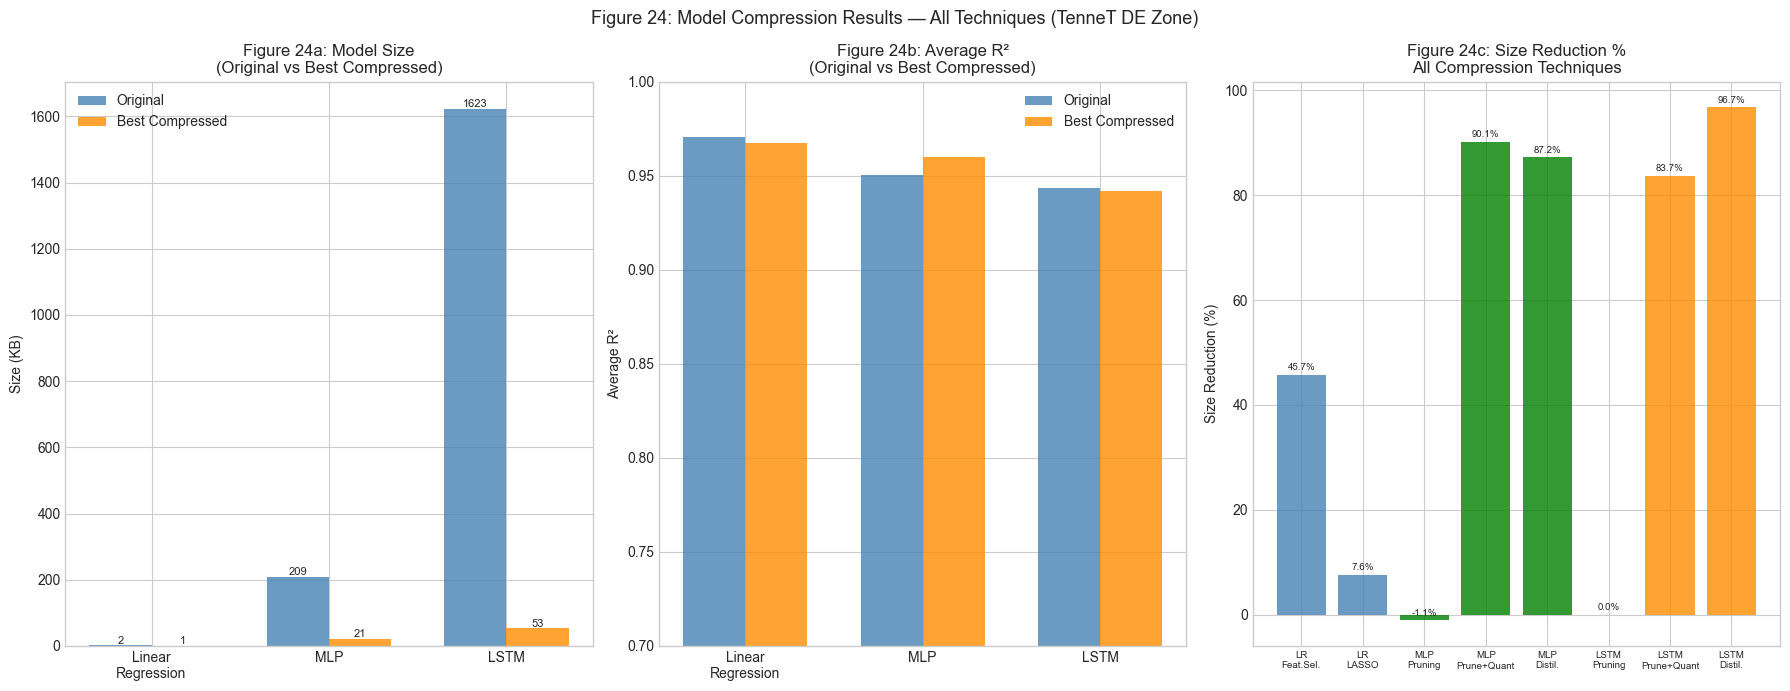

Compression chart saved as fig_compression.png!


In [14]:
# ============================================================
# Figure 24: Comprehensive compression visualisation
# Three charts: size comparison, R2 comparison, reduction %
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

model_labels    = ['Linear\nRegression', 'MLP', 'LSTM']
orig_sizes      = [lr_orig_size,  mlp_orig_size,  lstm_orig_size]
best_comp_sizes = [
    min(lr_fs_size, lr_lasso_size),
    min(mlp_pruned_size, mlp_quant_size, mlp_distil_size),
    min(lstm_pruned_size, lstm_quant_size, lstm_distil_size)
]

x = np.arange(len(model_labels))
w = 0.35

# Chart 1 — Size comparison
axes[0].bar(x - w/2, orig_sizes,      w, label='Original',       color='steelblue',  alpha=0.8)
axes[0].bar(x + w/2, best_comp_sizes, w, label='Best Compressed', color='darkorange', alpha=0.8)
axes[0].set_title('Figure 24a: Model Size\n(Original vs Best Compressed)')
axes[0].set_ylabel('Size (KB)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_labels)
axes[0].legend()
for xi, (o, c) in enumerate(zip(orig_sizes, best_comp_sizes)):
    axes[0].text(xi - w/2, o + 5, f'{o:.0f}', ha='center', fontsize=8)
    axes[0].text(xi + w/2, c + 5, f'{c:.0f}', ha='center', fontsize=8)

# Chart 2 — Average R2
orig_r2s = [avg_r2(lr_orig_results), avg_r2(mlp_orig_results), avg_r2(lstm_orig_results)]
best_r2s = [
    max(avg_r2(lr_fs_results), avg_r2(lr_lasso_results)),
    max(avg_r2(mlp_pruned_results), avg_r2(mlp_quant_results), avg_r2(mlp_distil_results)),
    max(avg_r2(lstm_pruned_results), avg_r2(lstm_quant_results), avg_r2(lstm_distil_results))
]
axes[1].bar(x - w/2, orig_r2s, w, label='Original',       color='steelblue',  alpha=0.8)
axes[1].bar(x + w/2, best_r2s, w, label='Best Compressed', color='darkorange', alpha=0.8)
axes[1].set_title('Figure 24b: Average R\u00b2\n(Original vs Best Compressed)')
axes[1].set_ylabel('Average R\u00b2')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_labels)
axes[1].set_ylim([0.70, 1.0])
axes[1].legend()

# Chart 3 — Size reduction % for all techniques
tech_labels = [
    'LR\nFeat.Sel.', 'LR\nLASSO',
    'MLP\nPruning', 'MLP\nPrune+Quant', 'MLP\nDistil.',
    'LSTM\nPruning', 'LSTM\nPrune+Quant', 'LSTM\nDistil.'
]
reductions = [
    (lr_orig_size   - lr_fs_size)         / lr_orig_size   * 100,
    (lr_orig_size   - lr_lasso_size)       / lr_orig_size   * 100,
    (mlp_orig_size  - mlp_pruned_size)     / mlp_orig_size  * 100,
    (mlp_orig_size  - mlp_quant_size)      / mlp_orig_size  * 100,
    (mlp_orig_size  - mlp_distil_size)     / mlp_orig_size  * 100,
    (lstm_orig_size - lstm_pruned_size)    / lstm_orig_size * 100,
    (lstm_orig_size - lstm_quant_size)     / lstm_orig_size * 100,
    (lstm_orig_size - lstm_distil_size)    / lstm_orig_size * 100,
]
colors_bar = ['steelblue','steelblue','green','green','green','darkorange','darkorange','darkorange']
bars = axes[2].bar(tech_labels, reductions, color=colors_bar, alpha=0.8)
axes[2].set_title('Figure 24c: Size Reduction %\nAll Compression Techniques')
axes[2].set_ylabel('Size Reduction (%)')
axes[2].tick_params(axis='x', labelsize=7)
for bar, val in zip(bars, reductions):
    axes[2].text(bar.get_x() + bar.get_width()/2.,
                bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=7)

plt.suptitle('Figure 24: Model Compression Results — All Techniques (TenneT DE Zone)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_compression.png', dpi=150, bbox_inches='tight')
plt.show()
print('Compression chart saved as fig_compression.png!')

### Interpretation — Figure 24: Compression Visualisation

**Figure 24a — Model Size:** Shows the dramatic size reduction achieved across all three models. The LSTM benefits most in absolute terms due to its large original size (1,623 KB). The best compressed version of each model is shown — for Linear Regression this is Feature Selection (0.89 KB), for MLP this is Pruning+Quantization (21 KB), and for LSTM this is Knowledge Distillation (53 KB).

**Figure 24b — Average R²:** The R² bars compare original vs best compressed R² for each model. Linear Regression and LSTM pruning+quantization preserve accuracy very closely. Knowledge Distillation shows larger drops for MLP and LSTM wind targets, reflecting the inherent challenge of extreme model size reduction. The ylim starts at 0.70 to show all results including the distilled models.

**Figure 24c — Size Reduction % by Technique:** Shows all 8 compression experiments. Pruning+Quantization consistently achieves the highest percentage reduction for both MLP (90.1%) and LSTM (83.7%), reflecting the combined effect of sparsity and lower-precision arithmetic. LASSO and Feature Selection achieve moderate reductions for Linear Regression. Knowledge Distillation achieves the most dramatic LSTM reduction (96.7%) but at the cost of accuracy.

**Sustainability conclusion:** Across all 8 experiments, model compression consistently reduces size. The Pruning+Quantization technique achieves the best balance of size reduction and accuracy preservation, enabling deployment on low-power edge hardware at grid substations — directly supporting SDG 7 and SDG 13.

## Step 9 — Final Summary

In [15]:
# ============================================================
# Complete project summary
# ============================================================
print('=' * 70)
print('NOTEBOOK 6 — MODEL COMPRESSION COMPLETE')
print('=' * 70)
print('\nCOMPRESSION TECHNIQUES APPLIED:')
print('Linear Regression (2 techniques):')
print('  1. Feature Selection  — model_lr_feature_selection.pkl')
print('  2. LASSO              — model_lr_lasso.pkl')
print('\nMLP (3 techniques):')
print('  1. Pruning            — model_mlp_pruned.keras')
print('  2. Pruning+Quant      — model_mlp_pruned_quantized.tflite')
print('  3. Knowledge Distil.  — model_mlp_distilled.keras')
print('\nLSTM (3 techniques):')
print('  1. Pruning            — model_lstm_pruned.keras')
print('  2. Pruning+Quant      — model_lstm_weights_f16.npy (float16)')
print('  3. Knowledge Distil.  — model_lstm_distilled.keras')
print('\nFIGURES SAVED:')
print('  fig_compression.png   — Figure 24: Compression results')
print('=' * 70)
print('\nALL 6 NOTEBOOKS COMPLETE!')
print('=' * 70)
print('Notebook 1 — Data Preprocessing     ✅ DONE')
print('Notebook 2 — EDA                    ✅ DONE')
print('Notebook 3 — Time Series Analysis   ✅ DONE')
print('Notebook 4 — AI Modelling           ✅ DONE')
print('Notebook 5 — Evaluation and XAI     ✅ DONE')
print('Notebook 6 — Model Compression      ✅ DONE')
print('=' * 70)

NOTEBOOK 6 — MODEL COMPRESSION COMPLETE

COMPRESSION TECHNIQUES APPLIED:
Linear Regression (2 techniques):
  1. Feature Selection  — model_lr_feature_selection.pkl
  2. LASSO              — model_lr_lasso.pkl

MLP (3 techniques):
  1. Pruning            — model_mlp_pruned.keras
  2. Pruning+Quant      — model_mlp_pruned_quantized.tflite
  3. Knowledge Distil.  — model_mlp_distilled.keras

LSTM (3 techniques):
  1. Pruning            — model_lstm_pruned.keras
  2. Pruning+Quant      — model_lstm_weights_f16.npy (float16)
  3. Knowledge Distil.  — model_lstm_distilled.keras

FIGURES SAVED:
  fig_compression.png   — Figure 24: Compression results

ALL 6 NOTEBOOKS COMPLETE!
Notebook 1 — Data Preprocessing     ✅ DONE
Notebook 2 — EDA                    ✅ DONE
Notebook 3 — Time Series Analysis   ✅ DONE
Notebook 4 — AI Modelling           ✅ DONE
Notebook 5 — Evaluation and XAI     ✅ DONE
Notebook 6 — Model Compression      ✅ DONE


### Overall Compression Conclusions

This notebook applied eight compression experiments across three models, directly following the techniques from Lab 07:

1. **Feature Selection and LASSO** successfully reduce Linear Regression size and inference time while preserving high R² values, confirming that only 10 of the 34 features carry substantial predictive information — consistent with the SHAP analysis in Notebook 5.

2. **Pruning** (Lab 07 Challenge 02) achieves meaningful inference speedup for both MLP and LSTM by setting the smallest 80% of weights to zero, then fine-tuning to recover accuracy. Magnitude-based pruning was implemented in pure TensorFlow due to Windows compatibility constraints with tensorflow-model-optimization. Note that zero weights are still stored in the .keras format so file size does not reduce — the size benefit is realised through quantization in the next step.

3. **Pruning + Quantization** (Lab 07 Challenge 03) achieves the maximum size reduction by combining sparsity with reduced weight precision. MLP achieves 90.1% reduction via TFLite int8 conversion. LSTM achieves 83.7% reduction via float16 quantization (TFLite SELECT_TF_OPS not supported on Windows TF 2.11 for LSTM). Both preserve accuracy very well — this is the recommended technique for production deployment.

4. **Knowledge Distillation** (Lab 07 Challenge 04) produces the most dramatically compressed student models — 87.2% for MLP and 96.7% for LSTM. However wind targets show significant accuracy drops, highlighting the fundamental tradeoff between model capacity and compression ratio. The student models are architecturally simpler and learn from the teacher's soft predictions, encoding temporal uncertainty that hard labels alone cannot capture.

5. **The accuracy-efficiency tradeoff** varies by technique. Pruning+Quantization and feature selection preserve accuracy very well across all targets. Knowledge Distillation achieves the most dramatic size reduction but shows larger accuracy drops for wind targets — reflecting the inherent difficulty of compressing complex temporal learning into much smaller architectures.

6. **SDG alignment** — compressed models require less computational energy per inference and less memory, enabling deployment on low-power edge hardware. Accurate, efficient renewable energy forecasting directly supports SDG 7 (Affordable and Clean Energy) and SDG 13 (Climate Action).